# Notebook 05b: Is the clock right? Timing errors and chronos

**Goal (about 1.5 hours; after notebook 05):** learn what a clock error does to a seismic dataset, find the evidence for one that is already sitting in our catalog (station STAR), and run the method the Denolle Lab uses to measure and fix clock errors, **chronos**, on a synthetic pair of stations where the answer is known. You leave with a diagnostic you can run on any station, and a ready-to-run cell for the real STAR data.

Background reading (20 minutes):

- The README and the *HYS14 — Correction Method* document of [chronos](https://github.com/MaleenKidiwela/chronos) (Maleen Kidiwela, UW). Read sections 1, 3, 4, 5 and 12 of the method doc; skim the rest. Its companion package **chronfix** applies the correction to miniSEED.
- Shelly, Moran & Thelen (2013), *GRL* 40, 1506-1512, section 2.1, the paragraph that begins "Since variability in digitizers' sampling intervals...". It explains why the 2009 Rainier relocation used only stations "digitized on a common timescale", which is this lesson in one sentence.

In [1]:
# --- setup: make the repo importable and keep figures inline ---
import sys, warnings
from pathlib import Path
REPO = Path.cwd().parent if (Path.cwd() / "../rainier_sws").exists() else Path.cwd()
sys.path.insert(0, str(REPO))
warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
from rainier_sws import paths, data, measure, quality, stats, timing
print("repo:", REPO)
print("chronos / chronfix importable:", timing.CHRONOS_AVAILABLE,
      "" if timing.CHRONOS_AVAILABLE else "(using the local copies of the chronos numerics in rainier_sws/timing.py)")

repo: /home/claude/repos/rainier-sws-tutorials
chronos / chronfix importable: True 


## 1. Why a splitting project cares about the clock

All three channels of a station go through one digitizer with one clock, so a wrong clock shifts Z, N and E together: **the splitting measurement itself (phi, dt) is immune to an absolute timing error.** So why spend a lesson on it? Four reasons, in the order they will bite this project:

1. **Locations.** The earthquake locations, and therefore the back azimuth and incidence angle that go into the LQT rotation (notebook 06, section 5), come from arrival times at many stations. A 50 ms error at one station is 50 ms x 6 km/s = 300 m of location error, and the whole 2025 swarm is only about 1 km across. STAR is the closest station to the swarm, so its picks carry a lot of weight in PNSN's locations.
2. **The phase-2 catalog.** The research plan rebuilds the catalog from permanent stations plus 240 GPS-timed nodes. Deep-learning pickers and associators (EQTransformer, PyOcto) assume all stations share one timescale; a station with a wandering clock produces outliers that the associator either drops or absorbs into bad locations.
3. **Cross-station methods.** Template matching and double-difference relocation compare waveforms *between* stations at the millisecond level. Shelly et al. (2013) dropped OBSR, PANH and LON from the 2009 relocation for exactly this reason: they were digitized on site, the rest of the network by a common digitizer in Seattle (which is also why those stations, including STAR, were analog telemetry in 2009: a different kind of timing problem, a fixed delay).
4. **Picks versus waveforms.** Our S windows are placed from the analyst's pick (notebook 08, section 6: a 30 ms shift of the pick flips phi on one event). PNSN picked on the same data stream we downloaded, so pick and waveform share any error today. The moment picks come from one system and waveforms from another (nodes, re-timed archives), that stops being true.

Vocabulary. A clock can have an **offset** (constant), a **drift** (the oscillator runs slightly fast or slow, so the error grows linearly or smoothly), and **jumps** (the instrument resynchronizes to GPS and the error snaps back to zero; chronos calls these *triggers*). A permanent station with GPS lock is good to about a millisecond. A station that loses GPS lock (snow on the antenna is a real failure mode on a volcano), an ocean-bottom seismometer (no GPS underwater; chronos' test case drifted by up to 60 s), or a node whose GPS fix is poor, drifts.

## 2. Diagnostic 1: the catalog already knows

For every pick we can compute a *residual*: observed travel time minus the travel time predicted from the location. The simplest possible prediction is a straight ray at one velocity, plus one constant per station that absorbs the site, the telemetry delay and any *constant* clock offset. `timing.travel_time_residuals` fits `t = R / V + c_station` to the whole strict catalog (14,000 picks, 40 stations) separately for P and S and returns what is left over.

The trick is to look at P and S together. A clock error adds the **same** number of seconds to P and to S. A location or velocity error adds time in proportion to slowness, so it moves S about Vp/Vs = 1.7 times more than P. Residuals that wander in time *identically* on P and S are a clock; residuals that wander with S bigger than P are the earth or the location. One more thing adds the same seconds to P and S: an error in the origin time. But an origin-time error hits every station that recorded the event, while a clock error hits one, which is why the comparison *between* stations below is part of the test.

In [2]:
cat = pd.read_csv(paths.STRICT_CATALOG_CSV)
sta = data.load_stations().set_index("station")
res, fit = timing.travel_time_residuals(cat, sta)
print(f"{len(res)} picks at {res.station.nunique()} stations; fitted Vp = {fit['vp_km_s']:.2f} km/s, Vs = {fit['vs_km_s']:.2f} km/s")
consts = pd.DataFrame({"const_p": fit["const_p"], "const_s": fit["const_s"]}).round(3)
consts.loc[["STAR", "RCM", "MILD", "LON", "RER", "PANH"]]

14285 picks at 40 stations; fitted Vp = 6.11 km/s, Vs = 3.67 km/s


,const_p,const_s
STAR,0.008,0.158
RCM,-0.026,0.121
MILD,0.050,0.357
LON,0.064,0.357
RER,0.056,0.329
PANH,0.027,0.379


The constants are not clock offsets by themselves: they are dominated by the very crude velocity model (one number for a volcano) and by elevation. Compare them only with care. What matters next is how the residual *changes with time* at each station.

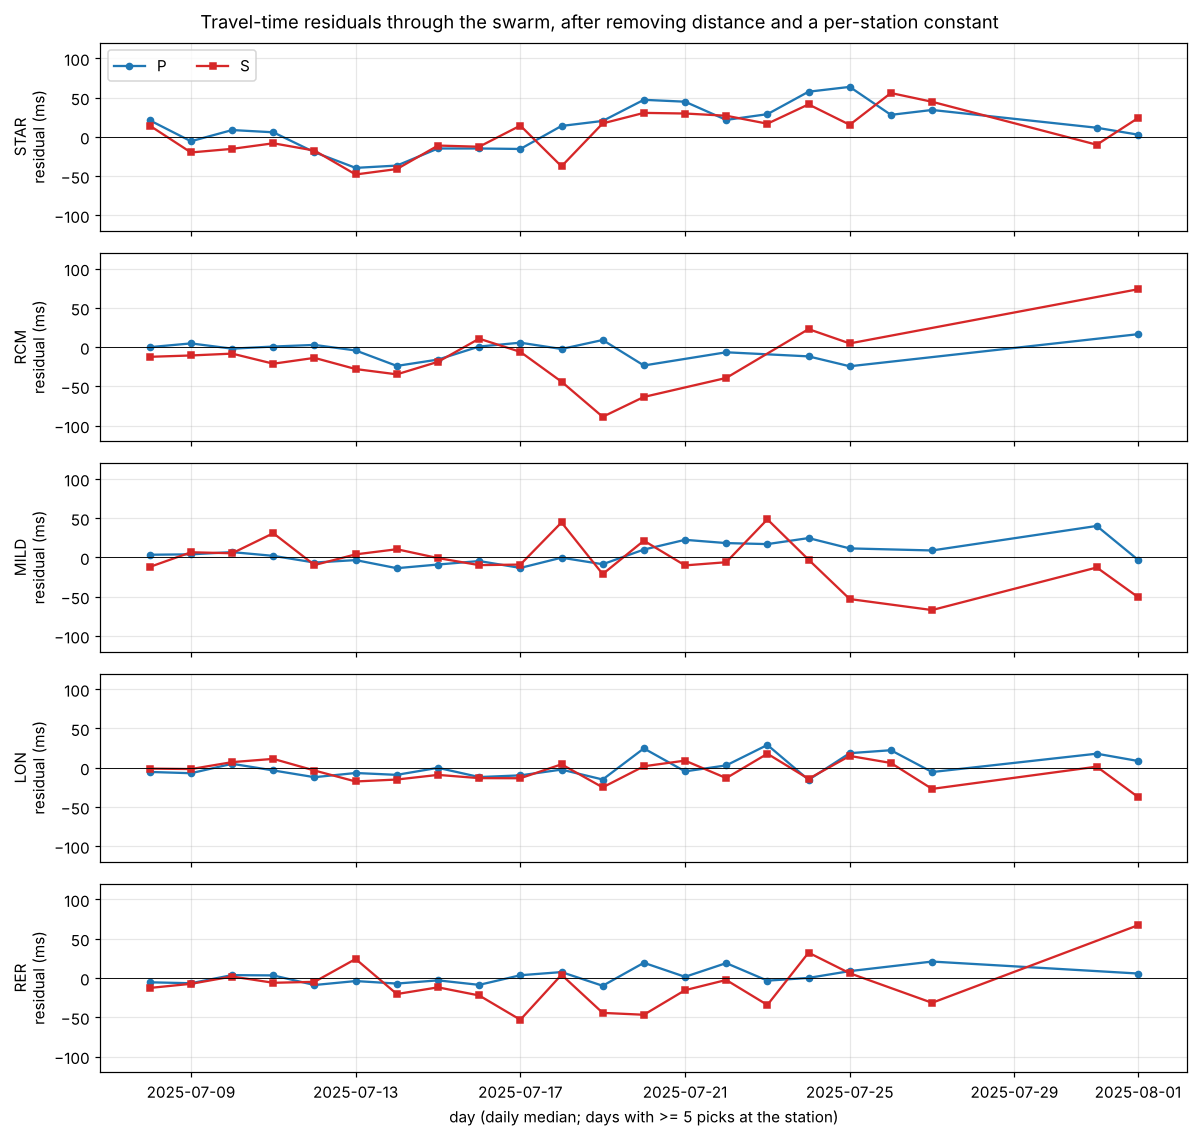

In [3]:
STATIONS = ["STAR", "RCM", "MILD", "LON", "RER"]
daily = {s: timing.daily_residuals(res, s) for s in STATIONS}

fig, axes = plt.subplots(len(STATIONS), 1, figsize=(11, 2.1 * len(STATIONS)), sharex=True, sharey=True)
for ax, s in zip(axes, STATIONS):
    d = daily[s]
    ax.plot(d.index, 1000 * d.res_p, "o-", ms=4, color="tab:blue", label="P")
    ax.plot(d.index, 1000 * d.res_s, "s-", ms=4, color="tab:red", label="S")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_ylabel(f"{s}\nresidual (ms)")
axes[0].legend(loc="upper left", ncol=2); axes[0].set_ylim(-120, 120)
axes[-1].set_xlabel("day (daily median; days with >= 5 picks at the station)")
fig.suptitle("Travel-time residuals through the swarm, after removing distance and a per-station constant")
plt.tight_layout()

Look at STAR against the other four. At STAR the residual walks from about -40 ms (July 13 to 14) up to +60 ms (July 24 to 25) and back, a swing of 100 ms, **and the P and S curves walk together**. At RCM, MILD and RER the P residual stays within about 20 ms of zero while the S residual scatters around it on its own; LON shows a smaller version of STAR's pattern (its P swing is about 40 ms).

Make that comparison quantitative: for each station, regress the daily S residual on the daily P residual. A clock gives slope 1 and high correlation; the earth gives slope around 1.7 with S dominated by its own (larger) noise; pure scatter gives nothing. (Ordinary regression with noise on the x-axis biases the slope toward zero, so a clock will show up as a slope somewhat below 1; the correlation is the more honest number.)

,n_days,slope_S_vs_P,corr,P range (ms)
station,,,,
STAR,22,0.76,0.75,103
RCM,17,0.79,0.26,41
MILD,21,-0.04,-0.02,54
LON,22,0.53,0.50,44
RER,20,-0.03,-0.01,31


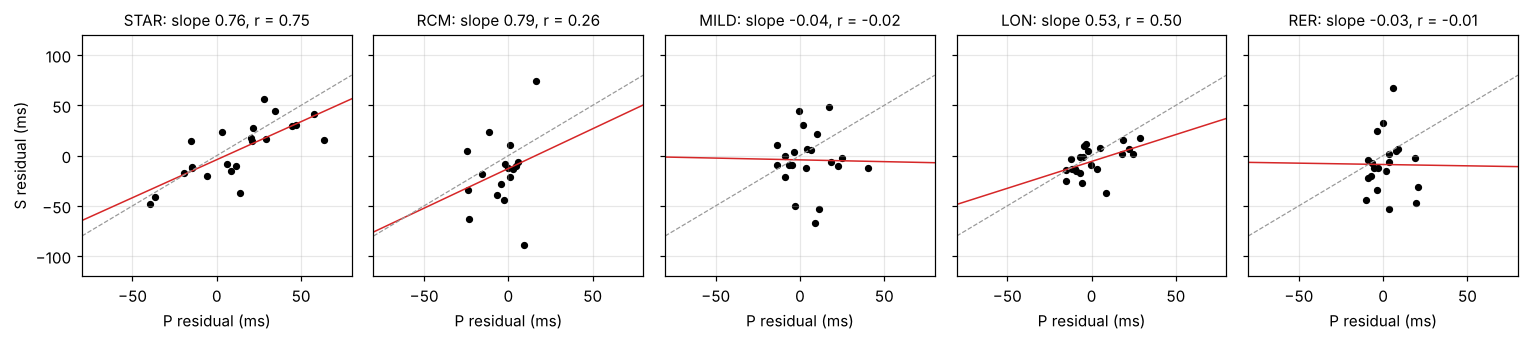

In [4]:
fig, axes = plt.subplots(1, len(STATIONS), figsize=(14, 3.2), sharex=True, sharey=True)
rows = []
for ax, s in zip(axes, STATIONS):
    d = daily[s]
    slope, intercept = np.polyfit(d.res_p, d.res_s, 1)
    r = np.corrcoef(d.res_p, d.res_s)[0, 1]
    rows.append({"station": s, "n_days": len(d), "slope_S_vs_P": round(slope, 2), "corr": round(r, 2),
                 "P range (ms)": round(1000 * (d.res_p.max() - d.res_p.min()))})
    ax.scatter(1000 * d.res_p, 1000 * d.res_s, s=14, c="k")
    xx = np.array([-80, 80]); ax.plot(xx, slope * xx + 1000 * intercept, "tab:red", lw=1)
    ax.plot(xx, xx, "0.6", ls="--", lw=0.8)           # slope 1 = clock
    ax.set_title(f"{s}: slope {slope:.2f}, r = {r:.2f}", fontsize=10); ax.set_xlabel("P residual (ms)")
axes[0].set_ylabel("S residual (ms)"); axes[0].set_xlim(-80, 80); axes[0].set_ylim(-120, 120)
plt.tight_layout()
pd.DataFrame(rows).set_index("station")

STAR stands out on both counts: the largest P swing in the network (about 100 ms, against 30 to 55 ms elsewhere) and the tightest P-to-S co-movement (correlation about 0.75, slope about 0.8, close to the dashed slope-1 line a clock would give). RCM has a similar slope but almost no correlation (its S residuals are just noisy); MILD and RER show no relation at all. LON is the one to keep an eye on: a correlation of 0.5 with a smaller swing. That is the signature of a STAR clock that moved by something like **100 ms peak to peak over the three weeks of the swarm**, not the signature of the earth.

Now the caveats, which are the reason this is "diagnostic 1" and not a conclusion:

- The travel-time model is one velocity and straight rays. Real paths to the summit station are the most unusual in the network, so STAR is also the station where model error is largest. The P-versus-S test guards against that, but only partly.
- PNSN *used* STAR's picks to locate these earthquakes. If STAR's clock was wrong, the location and origin time moved to accommodate it, so what we see is the part of the error that could **not** be absorbed. The true error could be larger.
- Analysts pick S on the horizontals, where the onset is emergent; the S residual is noisier than P everywhere (look at the y-axis ranges). A 20 ms S residual means little on its own.
- The swarm migrated. If the earthquakes that happened in late July were in a different place, the model error changes with time too, and LON's weaker version of the pattern could be that. (Exercise 1 asks you to check this with the back azimuths from notebook 03.)
- Twenty-two daily points is a small sample; a correlation of 0.75 on 22 points is significant, 0.5 is marginal.

So: the catalog says "STAR, July 2025, clock suspect, order 50 ms either way". To turn that into a measurement with an error bar you need data that does not depend on earthquakes, locations or analysts. That is diagnostic 2.

## 3. Diagnostic 2: ambient noise does not need earthquakes (the chronos method)

The ground is never still: ocean waves, wind, rivers and glaciers keep every seismometer moving. If you cross-correlate a long stretch of this noise recorded at two stations, the result converges to the response of the earth between them: a wave packet at the **travel time between the two stations**, at positive lag for energy travelling from a to b and at negative lag for energy travelling the other way (usually one side is stronger, because the noise sources are not evenly spread). The earth does not change from one hour to the next, so that packet must stay at the same lag. If it moves, a clock moved. That is the whole method; everything else is signal processing to make the peak visible:

1. Cut the day into overlapping windows (chronos: 30 minutes, 7.5-minute step).
2. In each window, detrend, taper, **whiten** (flatten the amplitude spectrum inside a band, so no single frequency dominates) and **one-bit** normalise (keep only the sign, so an earthquake or a gust of wind cannot dominate). Both functions in `rainier_sws.timing` are imported from chronos when it is installed.
3. Cross-correlate the two windows (`cc_segment`; convention: positive lag means station b lags station a).
4. Stack by **median** over the windows that fall in each UTC hour. The median rather than the mean, so a few bad windows cannot pull the result.
5. Pick the lag of the maximum of the envelope of CC squared (`peak_lag`). Squaring makes the pick insensitive to the sign of the wavelet; the envelope removes the oscillation inside the packet so the pick lands on the packet's centre rather than on one of its cycles. On real data restrict the search to one side of zero lag (`side="pos"` or `"neg"`, as chronos' `--side`), so the pick cannot flip between the two packets.
6. Clock error = peak lag minus the lag the pair *should* have (the **anchor**, taken from a period known to be good). Then an outlier filter (a rolling Hampel filter, from chronos) and a jump detector; each stable segment between jumps is smoothed; and chronfix resamples the raw data onto the true UTC grid using that model.

Two limits to remember. Resolution in lag is one sample: 0.125 s for chronos' 8 Hz ocean-bottom data, 10 ms at 100 Hz. chronos keeps the nearest-sample pick (its drifts are tens of seconds) and uses the curvature of a three-point parabola only for the error bar; we need tens of milliseconds, so `peak_lag` also moves the pick to the parabola's vertex. And resolution in time is one hour, because that is what the stack needs; a jump is only ever located to the hour, and an hourly value really describes the middle of its hour.

## 4. Try it where the answer is known

`timing.synthetic_pair` makes two stations recording the same band-limited noise field. Station A has a perfect clock. Station B records the same signal 1.2 s later (the inter-station travel time) and then **re-stamps it with a clock error you choose**, before independent noise is added to both. We choose a slow drift of 2 ms per hour for 40 hours, then a resync jump, then slower drift: 100 ms peak to peak, about what diagnostic 1 suggested for STAR, at a signal-to-noise ratio of 0.7 (the coherent part is weaker than the noise in any one window).

2 Trace(s) in Stream:
XX.REFA..HHZ | 2025-07-10T00:00:00.000000Z - 2025-07-12T23:59:59.950000Z | 20.0 Hz, 5184000 samples
XX.STAB..HHZ | 2025-07-10T00:00:00.000000Z - 2025-07-12T23:59:59.950000Z | 20.0 Hz, 5184000 samples


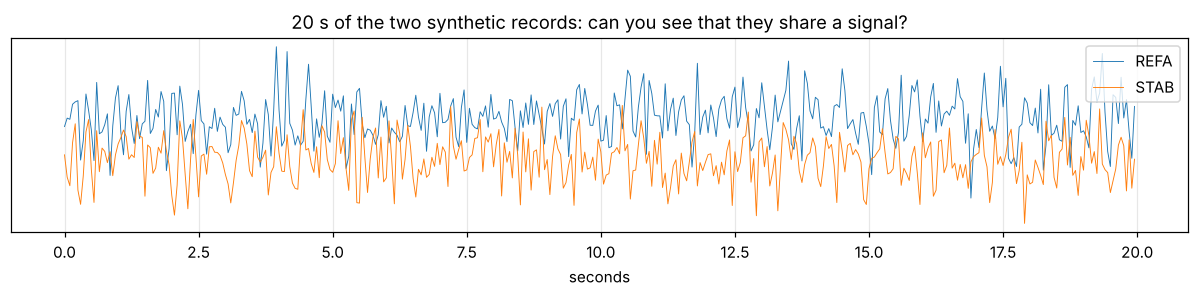

In [5]:
def true_delta_t(t_seconds):
    h = np.asarray(t_seconds, float) / 3600.0
    return np.where(h < 40, 0.002 * h, -0.02 + 0.0005 * (h - 40))      # seconds, positive = clock late

st, truth = timing.synthetic_pair(hours=72, fs=20.0, lag_s=1.2, delta_t_fn=true_delta_t, snr=0.7, seed=1)
print(st)
fig, ax = plt.subplots(figsize=(11, 2.8))
for tr, off in zip(st, (3, 0)):
    ax.plot(tr.times()[:400], tr.data[:400] + off, lw=0.6, label=tr.stats.station)
ax.set_xlabel("seconds"); ax.set_yticks([]); ax.legend(loc="upper right"); ax.set_title("20 s of the two synthetic records: can you see that they share a signal?")
plt.tight_layout()

You cannot, by eye. Cross-correlate every 10-minute window and look at them stacked up as an image. Then stack by hour.

1725 windows -> 72 hourly stacks; lag axis -10.0 to 10.0 s at 0.05000000000000071 s


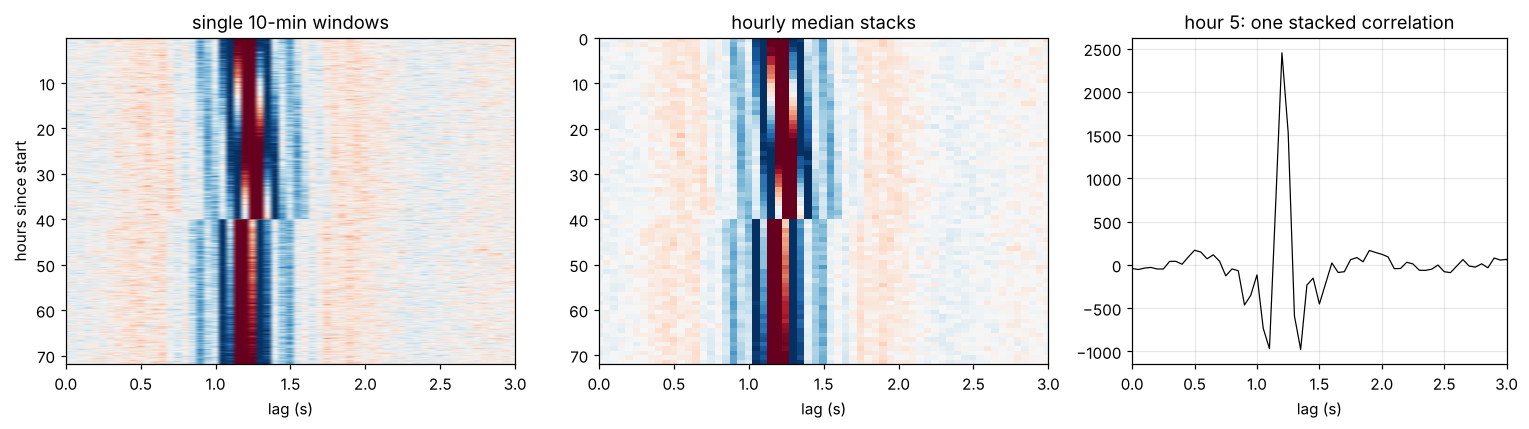

In [6]:
a, b, fs, t0 = timing.align_pair(st[0], st[1])
params = timing.CCParams(window_s=600, step_s=150, whiten_fmin=1.0, whiten_fmax=6.0, maxlag_s=10.0)
cc, mids, lags = timing.ccf_windows(a, b, fs, params)
cc_h, hours = timing.stack_by_hour(cc, mids, t0)
print(cc.shape[0], "windows ->", cc_h.shape[0], "hourly stacks; lag axis", lags[0], "to", lags[-1], "s at", lags[1]-lags[0], "s")

fig, axes = plt.subplots(1, 3, figsize=(14, 4), gridspec_kw={"width_ratios": [1.2, 1.2, 1]})
v = np.nanpercentile(np.abs(cc), 99)
axes[0].imshow(cc, aspect="auto", extent=[lags[0], lags[-1], mids[-1]/3600, mids[0]/3600], cmap="RdBu_r", vmin=-v, vmax=v)
axes[0].set_title("single 10-min windows"); axes[0].set_xlabel("lag (s)"); axes[0].set_ylabel("hours since start")
v = np.nanpercentile(np.abs(cc_h), 99)
axes[1].imshow(cc_h, aspect="auto", extent=[lags[0], lags[-1], len(hours), 0], cmap="RdBu_r", vmin=-v, vmax=v)
axes[1].set_title("hourly median stacks"); axes[1].set_xlabel("lag (s)")
for ax in axes[:2]: ax.set_xlim(0, 3); ax.grid(False)
axes[2].plot(lags, cc_h[5], "k", lw=0.8); axes[2].set_xlim(0, 3); axes[2].set_title("hour 5: one stacked correlation"); axes[2].set_xlabel("lag (s)")
plt.tight_layout()

The peak near 1.2 s is faint in the single windows and obvious in the hourly stacks, and you can already see it lean to larger lags as the hours go by (B's clock running late pushes B's copy of the signal to later stamped times), then snap back at hour 40. Now pick it.

nearest sample  median |error|  12.9 ms   p90  21.0 ms   max  25.0 ms
refined         median |error|   3.6 ms   p90   5.5 ms   max   6.2 ms


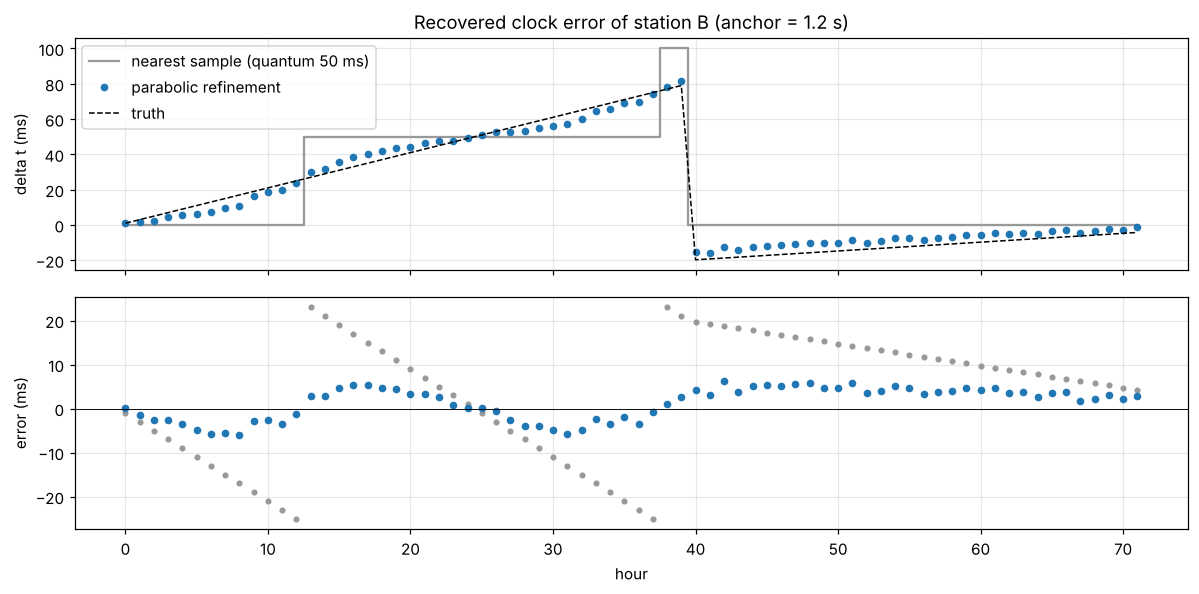

In [7]:
peak_nearest = timing.peak_lag(cc_h, lags, refine=False)
peak = timing.peak_lag(cc_h, lags, refine=True)
dt_nearest, _ = timing.delta_t_from_lags(peak_nearest, anchor=1.2)
dt_est, anchor = timing.delta_t_from_lags(peak, anchor=1.2)
hrs = np.arange(len(hours))

fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
axes[0].step(hrs, 1000 * dt_nearest, where="mid", color="0.6", label=f"nearest sample (quantum {1000/fs:.0f} ms)")
axes[0].plot(hrs, 1000 * dt_est, "o", ms=4, color="tab:blue", label="parabolic refinement")
axes[0].plot(hrs, 1000 * truth, "k--", lw=1, label="truth")
axes[0].set_ylabel("delta t (ms)"); axes[0].legend(loc="upper left"); axes[0].set_title("Recovered clock error of station B (anchor = 1.2 s)")
axes[1].plot(hrs, 1000 * (dt_nearest - truth), ".", color="0.6"); axes[1].plot(hrs, 1000 * (dt_est - truth), "o", ms=4, color="tab:blue")
axes[1].axhline(0, color="k", lw=0.6); axes[1].set_ylabel("error (ms)"); axes[1].set_xlabel("hour")
plt.tight_layout()
for name, est in (("nearest sample", dt_nearest), ("refined", dt_est)):
    e = np.abs(est - truth)
    print(f"{name:<15} median |error| {1000*np.nanmedian(e):5.1f} ms   p90 {1000*np.nanpercentile(e, 90):5.1f} ms   max {1000*np.nanmax(e):5.1f} ms")

With 20 Hz data the nearest-sample picker can only answer in steps of 50 ms, which is the size of the whole signal. The parabola through three envelope samples gets the error down to a few milliseconds, from a signal you could not see in a single window. That is the power of stacking, and the reason chronos works at all on 8 Hz ocean-bottom data.

Look at the error panel before moving on: it is not random. It is a sawtooth with a period of one sample, because a parabola is only an approximation to the envelope's shape and is biased toward the nearest sample. The cure is either a higher sampling rate (at 100 Hz the sawtooth is 1 ms) or a better interpolator (sinc); the error bar chronos computes from the same parabola does not know about this bias, which is worth remembering when you report one.

Now a simplified version of the chronos post-processing: one Hampel outlier filter pass (chronos runs several, with a continuity check), jump (trigger) detection between retained samples, a rolling median inside each stable segment (chronos: a slope test, then a 24-hour rolling median and a 6-hour moving average), and a `ClockModel` that chronfix can apply.

0 outlier hours removed; trigger (jump) at hours [39 40]


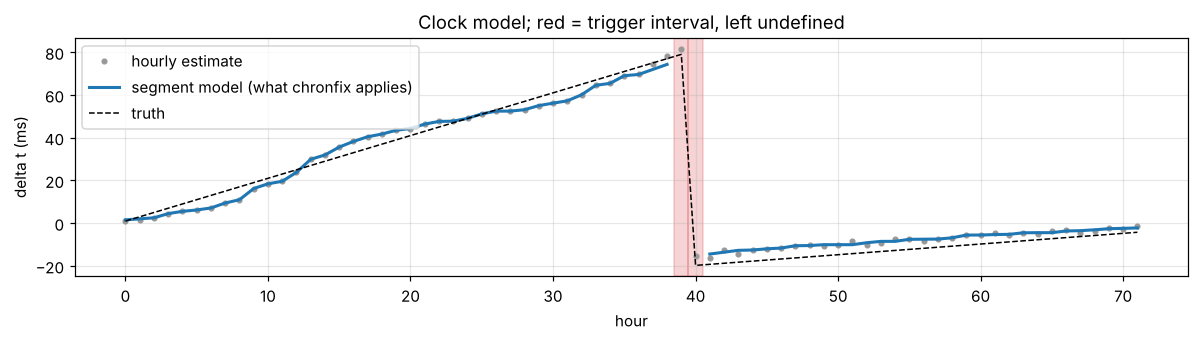

In [8]:
dt_clean, outliers, trig = timing.clean_delta_t(dt_est, window=25, threshold_sigma=3.5, min_abs_deviation=0.03, jump_threshold=0.05)
dt_model = timing.smooth_segments(dt_clean, trig, window=5)
print(f"{outliers.sum()} outlier hours removed; trigger (jump) at hours {np.where(trig)[0]}")

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(hrs, 1000 * dt_est, ".", color="0.6", label="hourly estimate")
ax.plot(hrs, 1000 * dt_model, "-", color="tab:blue", lw=2, label="segment model (what chronfix applies)")
ax.plot(hrs, 1000 * truth, "k--", lw=1, label="truth")
for h in np.where(trig)[0]: ax.axvspan(h - 0.5, h + 0.5, color="tab:red", alpha=0.2)
ax.set_xlabel("hour"); ax.set_ylabel("delta t (ms)"); ax.legend(loc="upper left"); ax.set_title("Clock model; red = trigger interval, left undefined")
plt.tight_layout()

Why not apply the hourly estimates directly? chronos found out the hard way (its `issue1.md` is worth reading): the raw hourly track is a staircase of picker quanta, and interpolating a staircase into a per-sample correction injects a sub-second *false* time warp into every window. Smoothing each stable segment first fixed it. Trigger hours are left undefined, and the corrected output is split there: the clock really was discontinuous.

Apply the model with chronfix (per-sample resampling of B onto the true UTC grid), then close the loop: cross-correlate the corrected B against A and check that the peak lag is flat.

ClockModel(station='STAB', n_hours=74, n_valid=74, n_triggers=1)


2 Trace(s) in Stream:
XX.STAB..HHZ | 2025-07-10T00:00:00.998445Z - 2025-07-11T14:59:58.898445Z | 20.0 Hz, 2807959 samples
XX.STAB..HHZ | 2025-07-11T17:00:00.014439Z - 2025-07-12T23:59:57.964439Z | 20.0 Hz, 2231960 samples


segment 0: residual clock error after correction, median 1.0 ms, MAD 1.3 ms, n = 39 h


segment 1: residual clock error after correction, median -2.3 ms, MAD 0.6 ms, n = 31 h


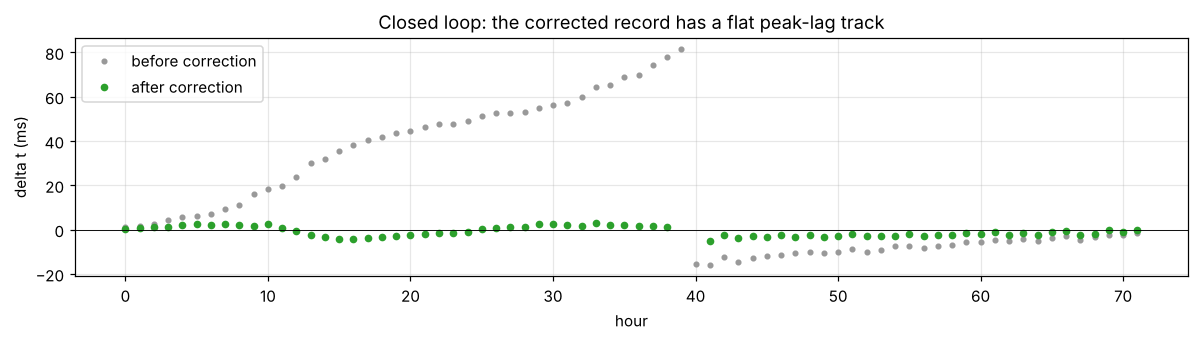

In [9]:
if timing.CHRONOS_AVAILABLE:
    model = timing.clock_model(hours, dt_model, trig, station="STAB")
    print(model)
    corrected = timing.correct_with_model(st.select(station="STAB"), model)
    print(corrected)

    fig, ax = plt.subplots(figsize=(11, 3.2))
    ax.plot(hrs, 1000 * dt_est, ".", color="0.6", label="before correction")
    for i, tr in enumerate(corrected):
        a2, b2, fs2, t02 = timing.align_pair(st[0], tr)
        d2 = timing.run_pair(a2, b2, fs2, t02, params)
        dt2, _ = timing.delta_t_from_lags(d2.peak_lag_s.values, anchor=1.2)
        h2 = (d2.hour.values - hours[0]) / np.timedelta64(1, "h")
        ax.plot(h2, 1000 * dt2, "o", ms=4, color="tab:green", label="after correction" if i == 0 else None)
        print(f"segment {i}: residual clock error after correction, median {1000*np.nanmedian(dt2):.1f} ms, MAD {1000*np.nanmedian(np.abs(dt2-np.nanmedian(dt2))):.1f} ms, n = {len(dt2)} h")
    ax.axhline(0, color="k", lw=0.6); ax.set_xlabel("hour"); ax.set_ylabel("delta t (ms)"); ax.legend(loc="upper left")
    ax.set_title("Closed loop: the corrected record has a flat peak-lag track")
    plt.tight_layout()
else:
    print("chronfix is not installed in this environment; see environment.yml. The correction step is skipped.")

A millisecond or two is left: pick noise, plus a small systematic piece, because an hourly estimate describes the middle of its hour but is stamped at its start (half an hour of drift at 2 ms per hour is 1 ms). One detail hides in `timing.align_pair`: after correction B's first sample no longer falls on a whole-sample boundary of A's grid, and if you simply trim both traces "to the same time" the correlation inherits that fraction-of-a-sample offset as a bias. chronos met the full-size version of this mistake while validating its own correction: its loader dropped the trace start time altogether, so the corrected data were re-misaligned by the whole delta t and the correction appeared to do nothing (method doc, section 10). `align_pair` interpolates onto a common grid instead.

## 5. Doing it for real: STAR

What changes with real data:

- **A reference station with trusted timing.** The nearest permanent 3-component site is RCM (Camp Muir, 4.9 km from STAR, 3077 m), and diagnostic 1 says its clock is steady. For the swarm period itself there is something better: the Z5 nodal array (240 GPS-timed nodes, July 12 to August 12, 2025). Nodes 227 and 129 sit near Camp Muir, 5.2 to 5.7 km from STAR, and the node closest to the summit on the west side (node 44) is 6.6 km away. Ask Michael for access to that data; `fetch_continuous` works unchanged on it once it is on EarthScope or on disk.
- **The band and the window.** At 5 km on a volcano the coherent noise is at higher frequency than chronos' ocean-bottom case: start with whitening 1 to 8 Hz, 10-minute windows, data decimated to 50 Hz (lag quantum 20 ms before refinement). If the hourly stacks show no stable peak, try 0.5 to 2 Hz and 30-minute windows; glacier and river noise is strong on Rainier and may give a clear peak where you least expect it.
- **The anchor.** You do not know the true inter-station lag. chronos takes the median over a window believed to be good; here, use the days *before* July 8 (nothing was happening) or the median of the whole track, and remember that an anchor error is a constant offset, which never matters for drift.
- **Gaps.** `fetch_continuous` zero-fills and tapers gaps the way chronos does; a window that is all zeros is skipped.

The cell below is the complete run. It needs EarthScope (notebook 00 tells you whether you have it) and downloads about a week of two 100 Hz channels (about 250 MB before decimation), so it is switched off by default. STAR's location code is `01`, so the request uses location `*` (requesting the blank location code returns nothing, which once made the research repo believe STAR had no archived data at all). RCM carries more than one channel code; `fetch_continuous` keeps the longest matching trace and says which.

In [10]:
RUN_LIVE = False      # set True on a machine that can reach EarthScope; takes a few minutes
from obspy import UTCDateTime
if RUN_LIVE:
    t0, t1 = UTCDateTime(2025, 7, 6), UTCDateTime(2025, 7, 14)
    star = timing.fetch_continuous("UW", "STAR", t0, t1, channel="EHZ", target_fs=50.0)
    rcm = timing.fetch_continuous("UW", "RCM", t0, t1, channel="?HZ", target_fs=50.0)
    a, b, fs, tstart = timing.align_pair(rcm, star)         # a = reference (RCM), b = target (STAR)
    live = timing.CCParams(window_s=600, step_s=150, whiten_fmin=1.0, whiten_fmax=8.0, maxlag_s=10.0)
    track = timing.run_pair(a, b, fs, tstart, live)
    out = paths.DATA / "timing"; out.mkdir(exist_ok=True)
    track.to_csv(out / "peak_lag_RCM-STAR_2025-07.csv", index=False)
    np.save(out / "cc_hourly_RCM-STAR_2025-07.npy", track.attrs["cc_hourly"]); np.save(out / "lags_RCM-STAR.npy", track.attrs["lags"])
    dt_star, anchor = timing.delta_t_from_lags(track.peak_lag_s.values, anchor=None, target_is_b=True)
    fig, ax = plt.subplots(figsize=(11, 3.2))
    ax.plot(track.hour, 1000 * dt_star, "o", ms=3); ax.set_ylabel("STAR delta t (ms)"); ax.set_title(f"RCM-STAR, anchor lag {anchor:.3f} s")
    plt.tight_layout()
else:
    print("RUN_LIVE is False: skipping the EarthScope download. The code above is the whole recipe.")

RUN_LIVE is False: skipping the EarthScope download. The code above is the whole recipe.


When you have a real track, three things to do with it, in order:

1. Overlay it on the daily residuals of diagnostic 1 (same sign convention: positive means STAR's clock is late, so its picks are late, so its P residual is positive). If they agree in shape, you have measured the clock. If they disagree, say so; both diagnostics have assumptions and the disagreement is the finding.
2. If the drift is bigger than about 20 ms, tell Michael. PNSN and CVO need to know, and the phase-2 catalog must not be built on uncorrected STAR data.
3. Build the `ClockModel`, run `timing.correct_with_model` on the cached STAR event windows, and re-run notebook 06 on a few events with the corrected waveforms and the *same* picks. The measurements should change by exactly nothing (same clock on all three channels; the picks move with the data) **unless** the pick-to-waveform alignment was the problem. That experiment is the "timing correction applied to the pipeline" extension in the README.

## 6. Exercises

1. Diagnostic 1 assumes the swarm did not move. Split the STAR residuals by back azimuth or by distance (notebook 03, section 4) and redo the daily plot for each half. Does the P-S co-movement survive?
2. Run `travel_time_residuals` on the Western Rainier Seismic Zone stations (PR05, SIFT, RUSH, GNOB are in the strict catalog). Any station whose P and S residuals move together?
3. In section 4, change `snr` to 2.0 and to 0.3. At what signal-to-noise ratio does the hourly track fall apart, and does doubling the window overlap (`step_s=75`) buy anything back?
4. Add a second jump to `true_delta_t` and lower `jump_threshold` step by step. When does the trigger detector start flagging ordinary drift as jumps? That trade-off is why chronos reports triggers to the hour and leaves them undefined.
5. (Stretch) An event-based diagnostic 2: cross-correlate the P wave of each cached STAR event with the same event at RCM (waveforms in the research repo under `data/waveforms_strict_rcm/`) and compare the measured differential time with the differential of the picks. This uses the earthquakes but not the analyst.
6. (Stretch, a real contribution) `timing.correct_with_model` works around a boundary case in chronfix (segments touching a trigger are dropped because the trigger interval is closed and times are truncated to seconds). Write a two-line failing test against `chronfix.correct.correct_trace` and open an issue, with the test, on the chronos repository.

Next: `06_single_event_with_swspy.ipynb`, the real measurement; keep the clock in mind when you get to section 5 (incidence angle).